# 3장 비지도 학습


## 1. 비지도 학습의 종류
비지도 변환은 데이터를 새롭게 표현하여 사람이나 다른 머신러닝 알고리즘이 원래 데이터보다 쉽게 해석할 수 있도록 만드는 알고리즘
텍스트 문서, 차원축소(특성)

## 2. 비지도 학습의 도전과제
알고리즘이 뭔가 유용한 것을 학습했는지 평가

탐색적 분석 단계와 지도학습의 전처리 단계에서 사용

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from sklearn.datasets import load_breast_cancer, make_blobs, load_digits, fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, Normalizer
from sklearn.preprocessing import QuantileTransformer, PowerTransformer
from sklearn.decomposition import PCA, NMF
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

import mglearn

---
## 3. 데이터 전처리와 스케일 조정

- SVM, 신경망 같은 알고리즘은 특성 간 거리/크기를 직접 계산 → 스케일 차이가 크면 왜곡
- 스케일 조정은 y값을 사용하지 않으므로 **비지도 방식**

| 스케일러 | 기준 | 특징 |
|---------|------|------|
| StandardScaler | (x-평균)/분산 | 이상값에 민감 |
| RobustScaler | (x-중간값)/사분위 | 이상값에 강건 |
| MinMaxScaler | (x-min)/(max-min) | 0~1 사이 |
| Normalizer | x/‖x‖ | 행 기준, 벡터 길이=1 |

스포츠 관련 문서 두 개
문서 1 : 축구  2번 / 스포츠 2번 / 기타 2번
문서 2 : 축구  200번 / 스포츠 200번 / 기타 200번
길이가 100배 차이남
정규화는 방향

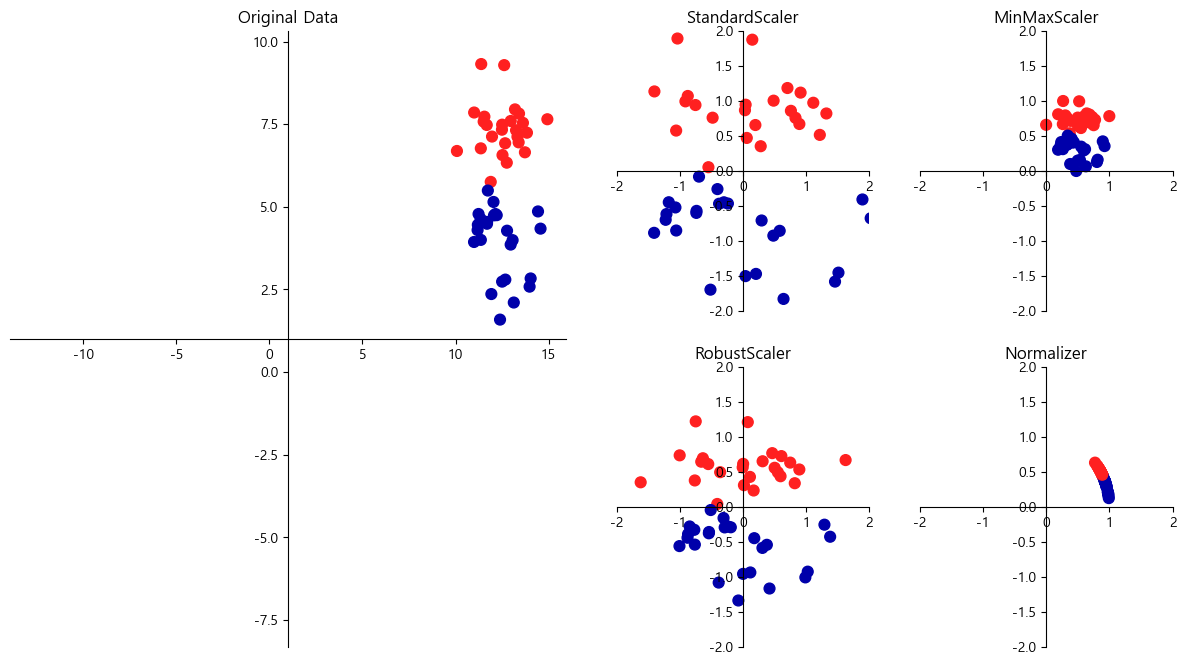

In [18]:
# 4가지 전처리 방법 시각화
mglearn.plots.plot_scaling()

### 3.2 데이터 변환 적용하기

In [19]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=1
)
print(X_train.shape)
print(X_test.shape)

(426, 30)
(143, 30)


In [20]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# fit: 훈련 세트의 최솟값/최댓값 계산 — y_train은 사용하지 않음
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('변환 전 특성 최솟값:\n', X_train.min(axis=0))
print('변환 후 특성 최솟값:\n', X_train_scaled.min(axis=0))
print('변환 전 특성 최댓값:\n', X_train.max(axis=0))
print('변환 후 특성 최댓값:\n', X_train_scaled.max(axis=0))

변환 전 특성 최솟값:
 [6.981e+00 9.710e+00 4.379e+01 1.435e+02 5.263e-02 1.938e-02 0.000e+00
 0.000e+00 1.060e-01 5.024e-02 1.153e-01 3.602e-01 7.570e-01 6.802e+00
 1.713e-03 2.252e-03 0.000e+00 0.000e+00 9.539e-03 8.948e-04 7.930e+00
 1.202e+01 5.041e+01 1.852e+02 7.117e-02 2.729e-02 0.000e+00 0.000e+00
 1.566e-01 5.521e-02]
변환 후 특성 최솟값:
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
변환 전 특성 최댓값:
 [2.811e+01 3.928e+01 1.885e+02 2.501e+03 1.634e-01 2.867e-01 4.268e-01
 2.012e-01 3.040e-01 9.575e-02 2.873e+00 4.885e+00 2.198e+01 5.422e+02
 3.113e-02 1.354e-01 3.960e-01 5.279e-02 6.146e-02 2.984e-02 3.604e+01
 4.954e+01 2.512e+02 4.254e+03 2.226e-01 9.379e-01 1.170e+00 2.910e-01
 5.774e-01 1.486e-01]
변환 후 특성 최댓값:
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


In [65]:
#테스트 데이터 변환
print('스케일 조정후 특성 최솟값:\n', X_test_scaled.min(axis=0))
print('스케일 조정후 특성 최댓값:\n', X_test_scaled.max(axis=0))

스케일 조정후 특성 최솟값:
 [-1.81222996 -2.06737851 -1.8093598  -1.3322574  -2.211637   -1.37662317
 -1.13037758 -1.26748337 -2.17546288 -1.80837819 -1.01242859 -1.56165364
 -1.00500553 -0.69943664 -1.47367685 -1.25837959 -1.00915683 -1.98136529
 -1.25800684 -0.94995993 -1.50393269 -2.17051176 -1.48235428 -1.10207811
 -2.1138052  -1.36201712 -1.36015587 -1.75887319 -2.04610582 -1.40034787]
스케일 조정후 특성 최댓값:
 [2.55081581 4.86840179 2.51371086 2.80994444 4.843984   4.77505487
 4.30664768 3.43424891 3.98144892 4.73433864 3.36507458 4.46261765
 3.99608321 2.80248527 8.55137018 6.50792273 3.56875682 4.94403713
 7.14192346 6.93405242 3.00531873 3.17488459 2.92823434 3.51114426
 2.51912396 4.48101793 4.5452017  2.68105574 4.02343478 3.43527489]


### 3.3 QuantileTransformer 와 PowerTransformer

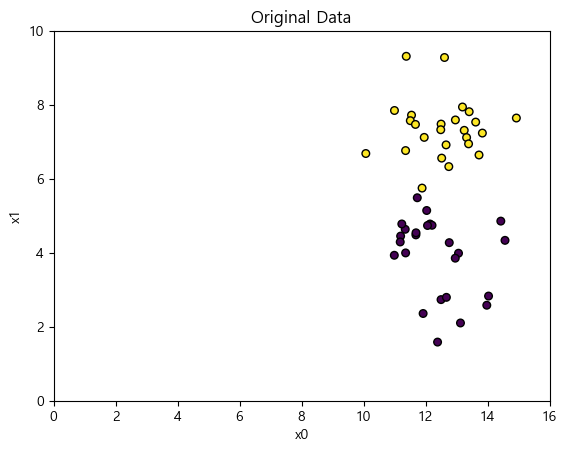

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.preprocessing import QuantileTransformer, StandardScaler, PowerTransformer

# 산점도 보기
X, y = make_blobs(n_samples=50, centers=2, random_state=4, cluster_std=1)
X += 3  # 전부 양수 영역으로 이동

plt.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolors='black')
plt.xlim(0, 16)
plt.xlabel('x0')
plt.ylim(0, 10)
plt.ylabel('x1')
plt.title('Original Data')
plt.show()

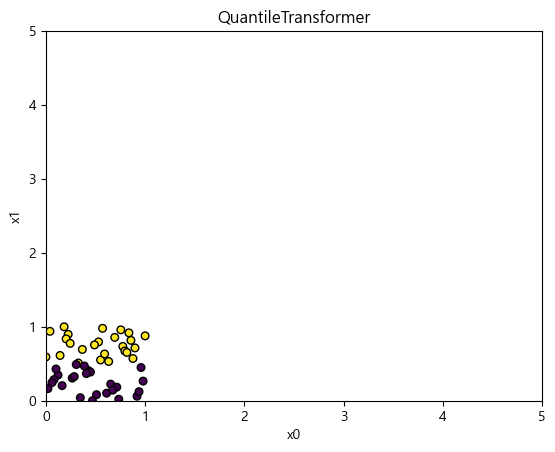

In [22]:
# QuantileTransformer 적용
scaler = QuantileTransformer(n_quantiles=50)
X_trans = scaler.fit_transform(X)

plt.scatter(X_trans[:, 0], X_trans[:, 1], c=y, s=30, edgecolors='black')
plt.xlim(0, 5)
plt.xlabel('x0')
plt.ylim(0, 5)
plt.ylabel('x1')
plt.title(type(scaler).__name__)  # __name__: 객체의 클래스 이름을 문자열로
plt.show()

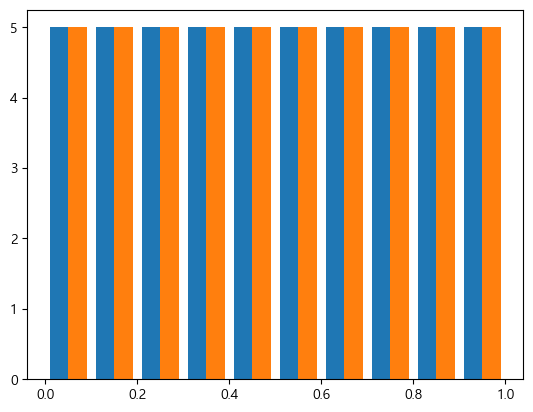

(50, 2)


In [ ]:
# 균등 분포 확인
plt.hist(X_trans)
plt.show()

# 분위수 개수 = n_quantiles, 기본값 1000 / 특성
# 속성의 크기: (n_quantiles, n_features)
print(scaler.quantiles_.shape)

In [24]:
# np.percentile: 지정한 분위에 해당하는 값을 반환
# 첫번째/1사분위/중간값/3사분위/마지막 값
x = np.array([[0], [5], [8], [9], [10]])
print(np.percentile(x[:, 0], [0, 25, 50, 75, 100]))

[ 0.  5.  8.  9. 10.]


In [25]:
# QuantileTransformer 변환 후: 값 → 분위(0~1)
x_trans = QuantileTransformer(n_quantiles=5).fit_transform(x)
print(np.percentile(x_trans[:, 0], [0, 25, 50, 75, 100]))

[0.   0.25 0.5  0.75 1.  ]


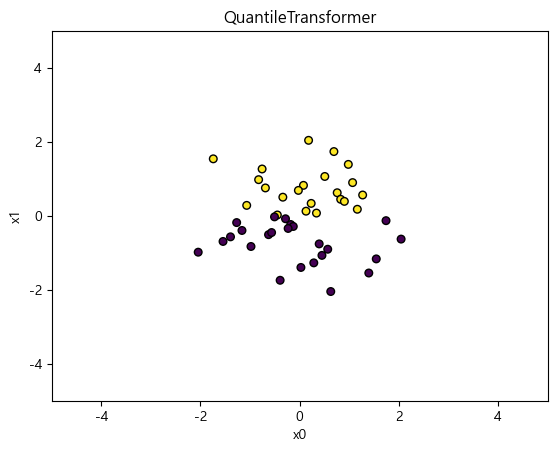

In [26]:
# output_distribution='normal' → 정규분포로 출력
scaler = QuantileTransformer(output_distribution='normal', n_quantiles=50)
X_trans = scaler.fit_transform(X)

plt.scatter(X_trans[:, 0], X_trans[:, 1], c=y, s=30, edgecolors='black')
plt.xlim(-5, 5)
plt.xlabel('x0')
plt.ylim(-5, 5)
plt.ylabel('x1')
plt.title(type(scaler).__name__)
plt.show()

#### PowerTransformer
데이터의 특성별로 정규분포 형태에 가깝도록 변환해주는 것
반지름은 반지름끼리, 면전은 면적끼리

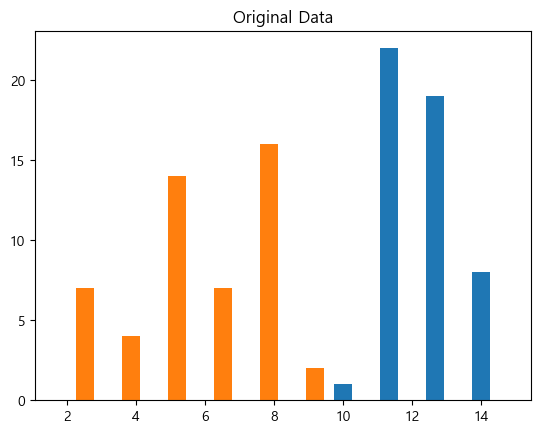

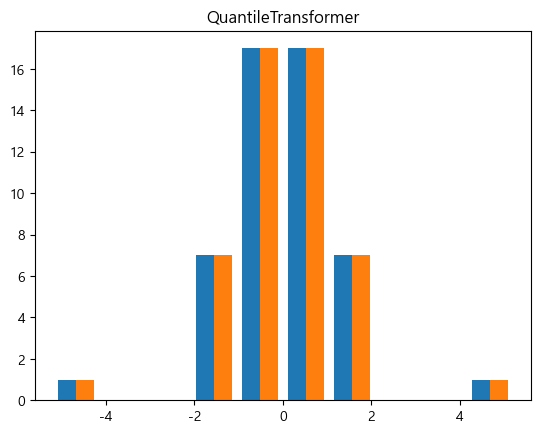

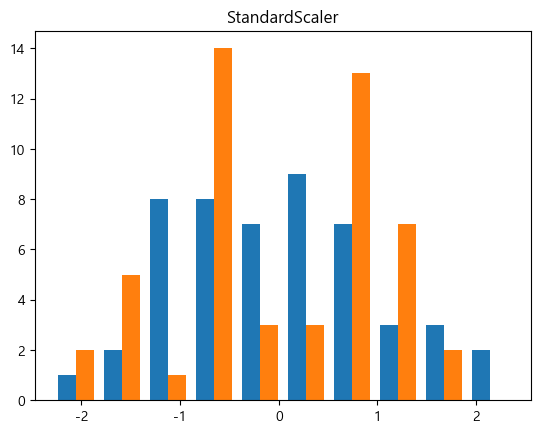

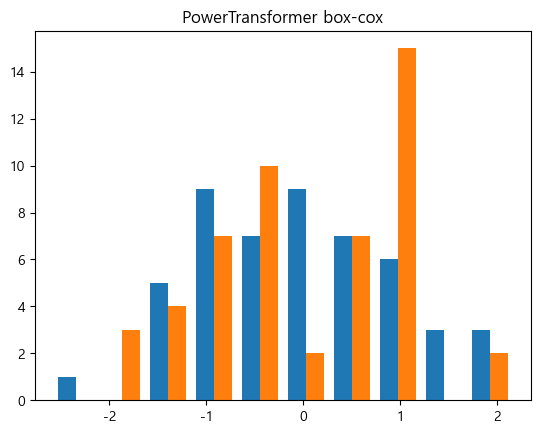

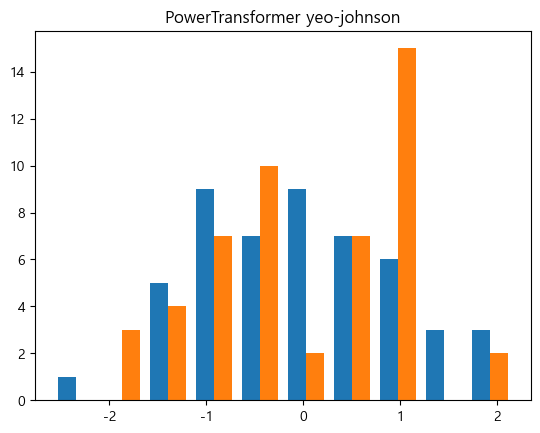

In [27]:
# 4가지 방법으로 정규분포 변환 비교
plt.hist(X)
plt.title('Original Data')
plt.show()

X_trans = QuantileTransformer(output_distribution='normal', n_quantiles=50).fit_transform(X)
plt.hist(X_trans)
plt.title('QuantileTransformer')
plt.show()

X_trans = StandardScaler().fit_transform(X)
plt.hist(X_trans)
plt.title('StandardScaler')
plt.show()

X_trans = PowerTransformer(method='box-cox').fit_transform(X)
plt.hist(X_trans)
plt.title('PowerTransformer box-cox')
plt.show()

X_trans = PowerTransformer(method='yeo-johnson').fit_transform(X)
plt.hist(X_trans)
plt.title('PowerTransformer yeo-johnson')
plt.show()

# box-cox: 양수 데이터만 가능 / yeo-johnson: 음수/양수 모두 가능

### 3.4 훈련/테스트 스케일 같은 방법으로 조정하기

- **fit은 훈련 데이터에만!** 테스트에 따로 fit하면 min/max가 달라져서 데이터 배열이 뒤죽박죽
- `scaler.fit(X_train)` → `scaler.transform(X_test)` (테스트는 transform만)

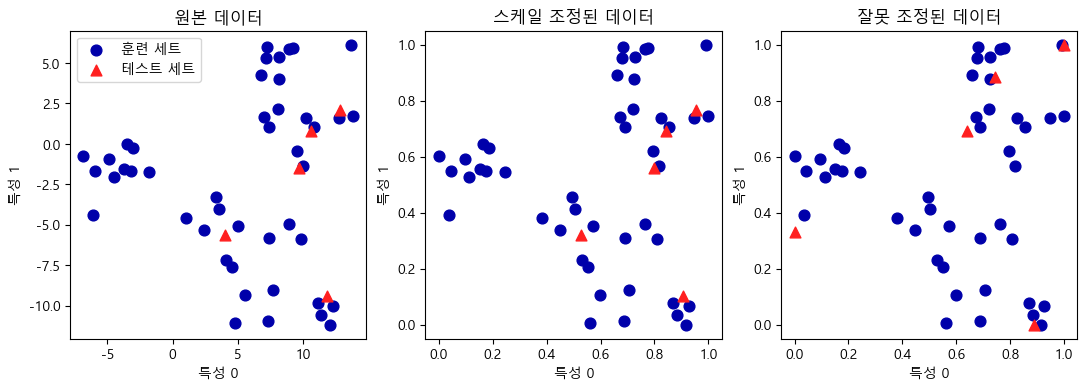

In [28]:
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=50, centers=5, random_state=4, cluster_std=2)
X_train, X_test = train_test_split(X, random_state=5, test_size=0.1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].scatter(X_train[:, 0], X_train[:, 1], c=mglearn.cm2(0), label='훈련 세트', s=60)
axes[0].scatter(X_test[:, 0], X_test[:, 1], marker='^', c=mglearn.cm2(1), label='테스트 세트', s=60)
axes[0].legend(loc='upper left')
axes[0].set_title('원본 데이터')

# 올바른 방법: 훈련 세트로 fit → 둘 다 transform
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

axes[1].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=mglearn.cm2(0), label='훈련 세트', s=60)
axes[1].scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], marker='^', c=mglearn.cm2(1), label='테스트 세트', s=60)
axes[1].set_title('스케일 조정된 데이터')

# 잘못된 방법: 테스트 세트를 따로 fit — 절대 이렇게 사용하면 안 됨!
test_scaler = MinMaxScaler()
test_scaler.fit(X_test)
X_test_scaled_badly = test_scaler.transform(X_test)

axes[2].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=mglearn.cm2(0), label='훈련 세트', s=60)
axes[2].scatter(X_test_scaled_badly[:, 0], X_test_scaled_badly[:, 1], marker='^', c=mglearn.cm2(1), label='테스트 세트', s=60)
axes[2].set_title('잘못 조정된 데이터')

for ax in axes:
    ax.set_xlabel('특성 0')
    ax.set_ylabel('특성 1')
plt.show()

In [29]:
# 단축 메서드: fit_transform
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# 메서드 체이닝 — fit과 transform 연달아 호출
X_scaled   = scaler.fit(X_train).transform(X_train)
# 위와 동일하지만 더 효율적
X_scaled_d = scaler.fit_transform(X_train)

### 3.5 지도 학습에서 데이터 전처리 효과

In [30]:
from sklearn.svm import SVC

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0
)

svm = SVC(gamma='auto')
svm.fit(X_train, y_train)
print('테스트 세트 정확도: {:.2f}'.format(svm.score(X_test, y_test)))

테스트 세트 정확도: 0.63


In [31]:
# MinMaxScaler 적용 후 SVM
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

svm.fit(X_train_scaled, y_train)
print('스케일 조정된 테스트 세트 정확도: {:.2f}'.format(svm.score(X_test_scaled, y_test)))

스케일 조정된 테스트 세트 정확도: 0.95


In [32]:
# StandardScaler 로 교체
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

svm.fit(X_train_scaled, y_train)
print('SVM test accuracy: {:.2f}'.format(svm.score(X_test_scaled, y_test)))

# axis=0 은 열, axis=1 은 행

SVM test accuracy: 0.97


---
## 4. 차원 축소, 특성 추출, 매니폴드 학습
비지도 학습의 목적 시각화하거나 데이터를 압출하거나 추가적인  처리를 위해 정보가 더 잘 드러나는 표현을 찾기 위해서

### 4.1 주성분 분석 (PCA)
복잡한 고차원 데이터를 정보 손실을 최소화하면서 단순하게 압축하는 기술
- 특성들이 **통계적으로 상관관계가 없도록** 데이터셋을 회전시키는 기술
- **분산이 가장 큰 방향** = 주성분 (데이터가 길게 늘어진 방향)
- 분산이 작은 방향 = 노이즈로 보고 버림 → 차원 축소
- PCA 전에 **StandardScaler 필수** (단위 차이로 분산이 왜곡되므로)

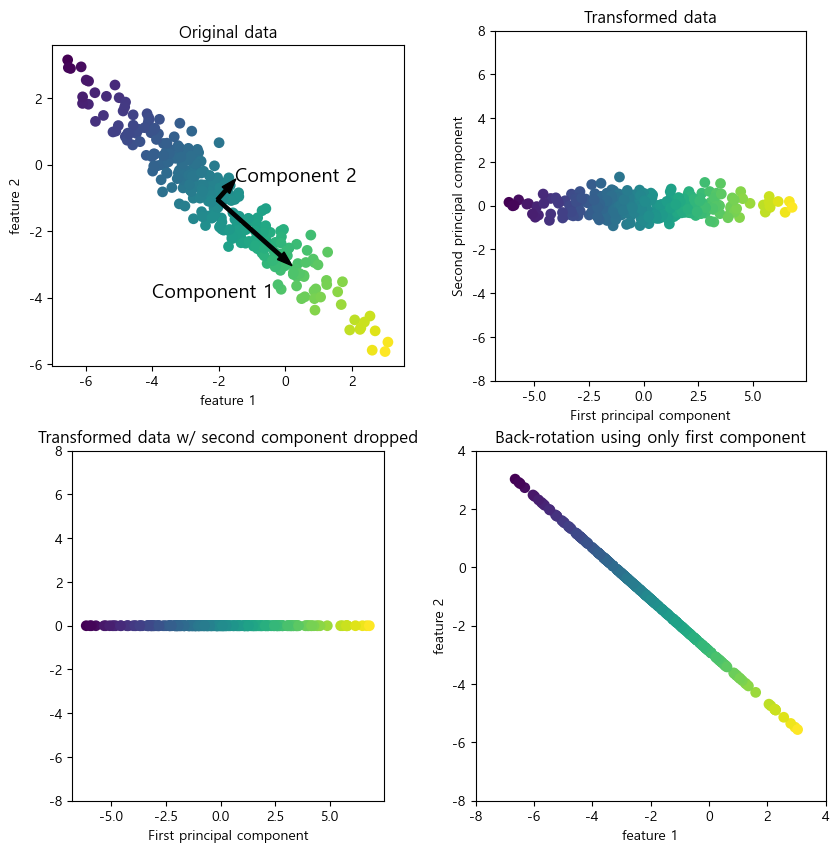

In [33]:
# PCA 동작 과정 시각화
mglearn.plots.plot_pca_illustration()

#### PCA를 적용해 유방암 데이터셋 시각화하기
데이터셋 특성이 30대이면 435개 산점도

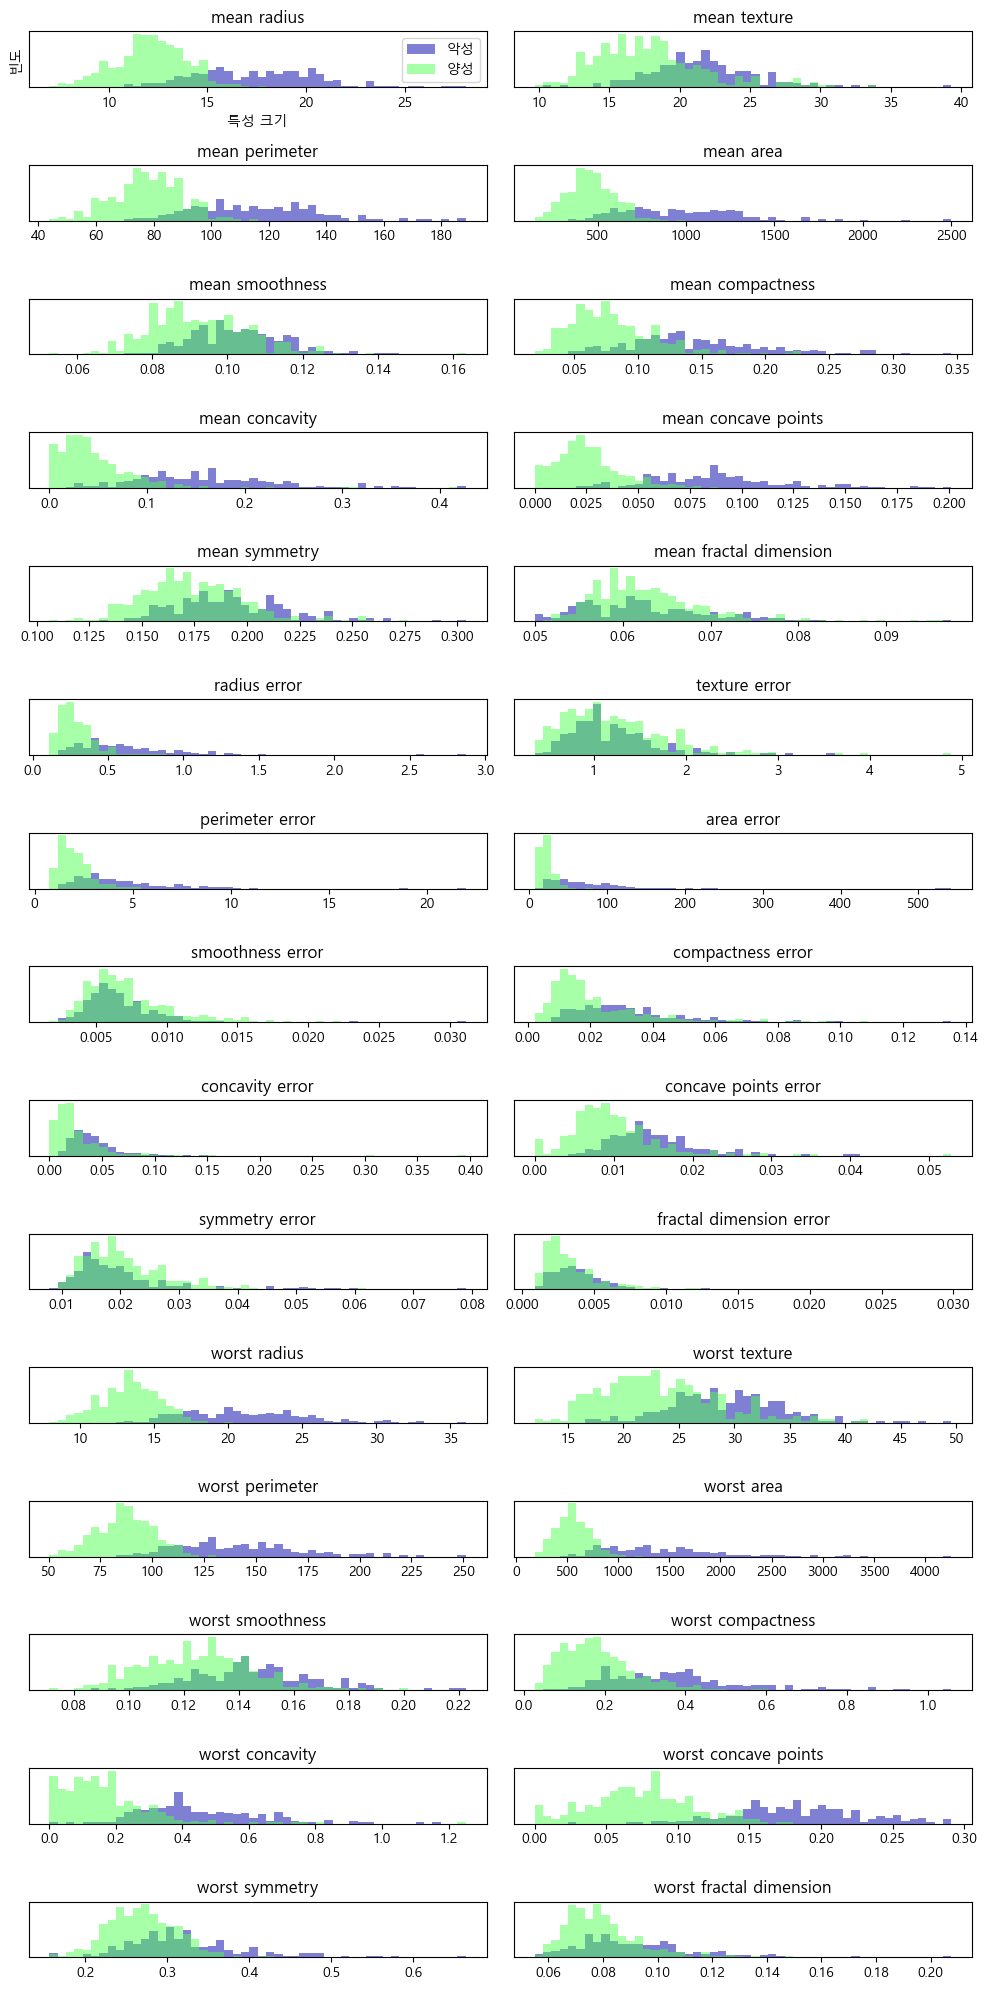

In [ ]:
# 유방암 데이터: 악성/양성 클래스별 히스토그램
fig, axes = plt.subplots(15, 2, figsize=(10, 20))

malignant = cancer.data[cancer.target == 0]
benign    = cancer.data[cancer.target == 1]

ax = axes.ravel()
for i in range(30):
    _, bins = np.histogram(cancer.data[:, i], bins=50)
    ax[i].hist(malignant[:, i], bins=bins, color=mglearn.cm3(0), alpha=.5)
    ax[i].hist(benign[:, i],    bins=bins, color=mglearn.cm3(2), alpha=.5)
    ax[i].set_title(cancer.feature_names[i])
    ax[i].set_yticks(())

ax[0].set_xlabel('특성 크기')
ax[0].set_ylabel('빈도')
ax[0].legend(['악성', '양성'], loc='best')
fig.tight_layout()
#초록색 - 양성 / 파란색 악성 

특성을 하나씩 볼 수 있지만 특성들 사이(A+B)의 상호작용은 못봄

In [35]:
# PCA 적용 전 StandardScaler로 스케일 조정
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA

cancer = load_breast_cancer()

scaler = StandardScaler()
scaler.fit(cancer.data)
X_scaled = scaler.transform(cancer.data)

In [36]:
# 처음 두 개 주성분만 유지
pca = PCA(n_components=2)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

print('원본 데이터 형태:', str(X_scaled.shape))
print('축소된 데이터 형태:', str(X_pca.shape))

원본 데이터 형태: (569, 30)
축소된 데이터 형태: (569, 2)


Text(0, 0.5, '두 번째 주성분')

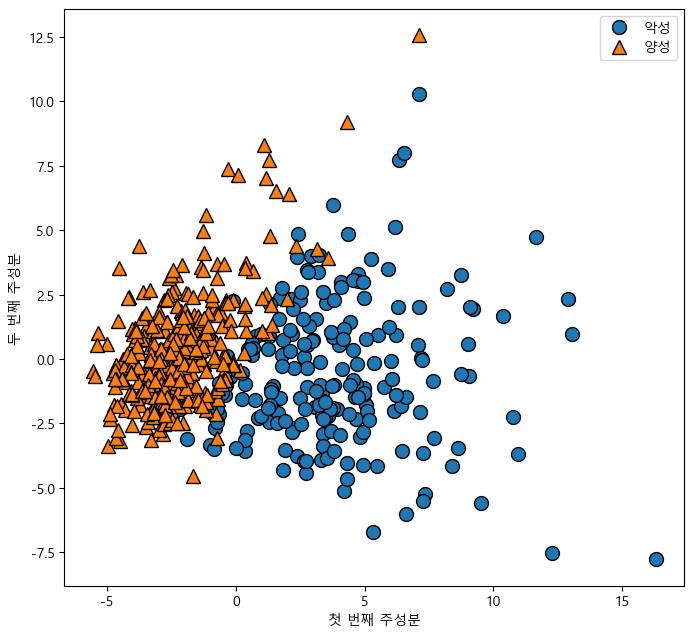

In [37]:
# 처음 두 주성분으로 산점도
plt.figure(figsize=(8, 8))
mglearn.discrete_scatter(X_pca[:, 0], X_pca[:, 1], cancer.target)
plt.legend(['악성', '양성'], loc='best')
plt.gca().set_aspect('equal')
plt.xlabel('첫 번째 주성분')
plt.ylabel('두 번째 주성분')

단점
두 축의 의미를 해석하기 어려움
비선형관계는 잘 못잡음

In [38]:
# components_: 주성분이 저장된 속성
print('PCA 주성분 형태:', pca.components_.shape)
print('PCA 주성분:', pca.components_)

PCA 주성분 형태: (2, 30)
PCA 주성분: [[ 0.21890244  0.10372458  0.22753729  0.22099499  0.14258969  0.23928535
   0.25840048  0.26085376  0.13816696  0.06436335  0.20597878  0.01742803
   0.21132592  0.20286964  0.01453145  0.17039345  0.15358979  0.1834174
   0.04249842  0.10256832  0.22799663  0.10446933  0.23663968  0.22487053
   0.12795256  0.21009588  0.22876753  0.25088597  0.12290456  0.13178394]
 [-0.23385713 -0.05970609 -0.21518136 -0.23107671  0.18611302  0.15189161
   0.06016536 -0.0347675   0.19034877  0.36657547 -0.10555215  0.08997968
  -0.08945723 -0.15229263  0.20443045  0.2327159   0.19720728  0.13032156
   0.183848    0.28009203 -0.21986638 -0.0454673  -0.19987843 -0.21935186
   0.17230435  0.14359317  0.09796411 -0.00825724  0.14188335  0.27533947]]


Text(0, 0.5, '주성분')

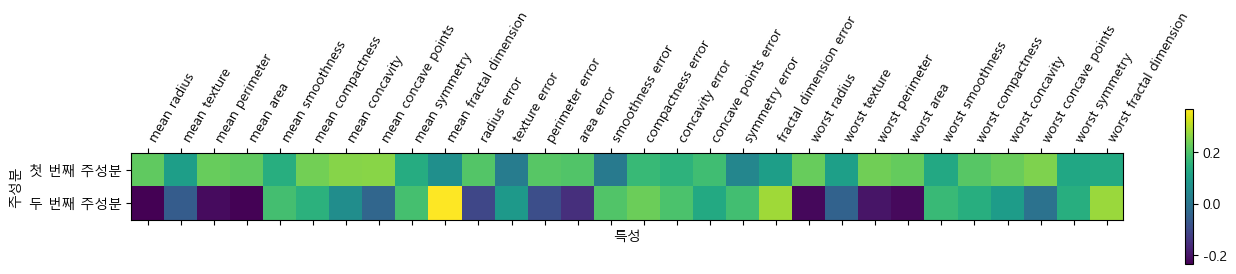

In [39]:
# 히트맵으로 시각화 — 양수=노란색, 음수=보라색
plt.matshow(pca.components_, cmap='viridis')
plt.yticks([0, 1], ['첫 번째 주성분', '두 번째 주성분'])
plt.colorbar()
plt.xticks(range(len(cancer.feature_names)),
           cancer.feature_names, rotation=60, ha='left')
plt.xlabel('특성')
plt.ylabel('주성분')

#### 고유얼굴(eigenface) 특성 추출 — LFW 데이터셋

people.images.shape: (3023, 87, 65)
클래스 개수: 62


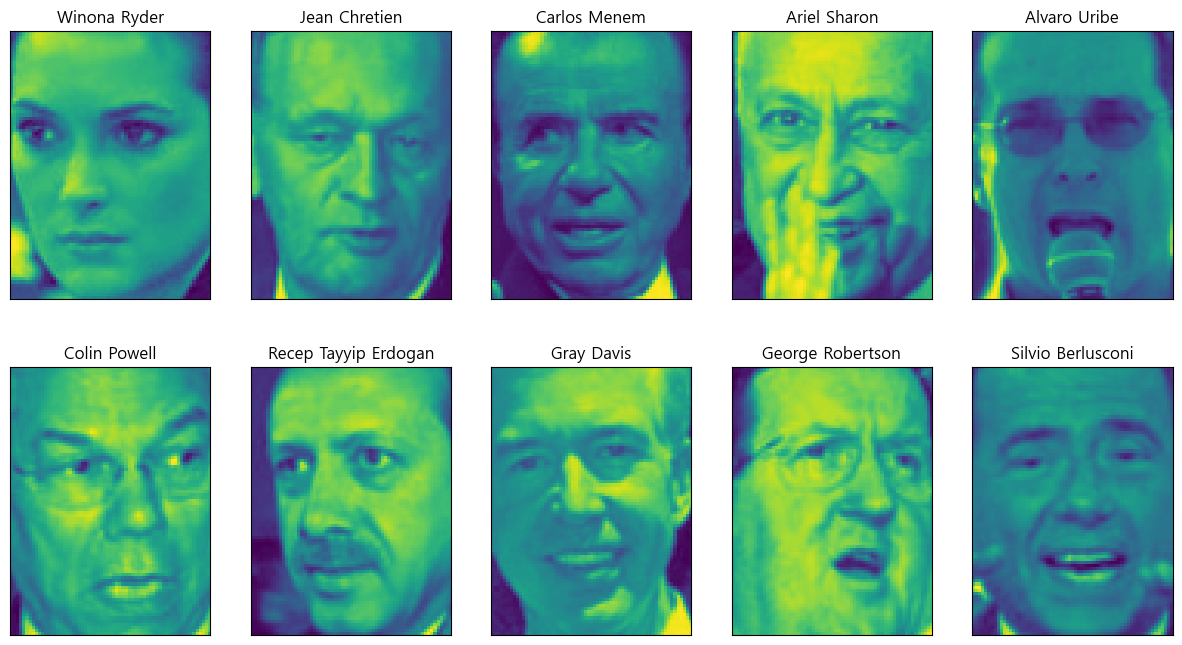

In [ ]:
# LFW 데이터셋 다운로드 
people = fetch_lfw_people(min_faces_per_person=20, resize=0.7)
image_shape = people.images[0].shape

fig, axes = plt.subplots(2, 5, figsize=(15, 8),
                          subplot_kw={'xticks': (), 'yticks': ()})
for target, image, ax in zip(people.target, people.images, axes.ravel()):
    ax.imshow(image)
    ax.set_title(people.target_names[target])

print('people.images.shape:', people.images.shape)
print('클래스 개수:', len(people.target_names))

In [41]:
# 각 타깃이 나타난 횟수
counts = np.bincount(people.target)
for i, (count, name) in enumerate(zip(counts, people.target_names)):
    print('{0:<25} {1:>3}'.format(name, count), end='   ')
    if (i + 1) % 3 == 0:
        print()

Alejandro Toledo           39   Alvaro Uribe               35   Amelie Mauresmo            21   
Andre Agassi               36   Angelina Jolie             20   Ariel Sharon               77   
Arnold Schwarzenegger      42   Atal Bihari Vajpayee       24   Bill Clinton               29   
Carlos Menem               21   Colin Powell              236   David Beckham              31   
Donald Rumsfeld           121   George Robertson           22   George W Bush             530   
Gerhard Schroeder         109   Gloria Macapagal Arroyo    44   Gray Davis                 26   
Guillermo Coria            30   Hamid Karzai               22   Hans Blix                  39   
Hugo Chavez                71   Igor Ivanov                20   Jack Straw                 28   
Jacques Chirac             52   Jean Chretien              55   Jennifer Aniston           21   
Jennifer Capriati          42   Jennifer Lopez             21   Jeremy Greenstock          24   
Jiang Zemin                20 

In [42]:
# 데이터 편중 제거: 사람마다 50개 이미지만 선택
mask = np.zeros(people.target.shape, dtype=bool)
for target in np.unique(people.target):
    mask[np.where(people.target == target)[0][:50]] = 1

X_people = people.data[mask]
y_people = people.target[mask]

# 0~255 픽셀 값을 0~1 스케일로 조정 (MinMaxScaler 적용과 거의 같음)
X_people = X_people / 255.

In [43]:
# 1-최근접 이웃으로 얼굴 인식 (원본 픽셀)
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_people, y_people, stratify=y_people, random_state=0
)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
print('1-최근접 이웃의 테스트 세트 점수: {:.2f}'.format(knn.score(X_test, y_test)))

1-최근접 이웃의 테스트 세트 점수: 0.22


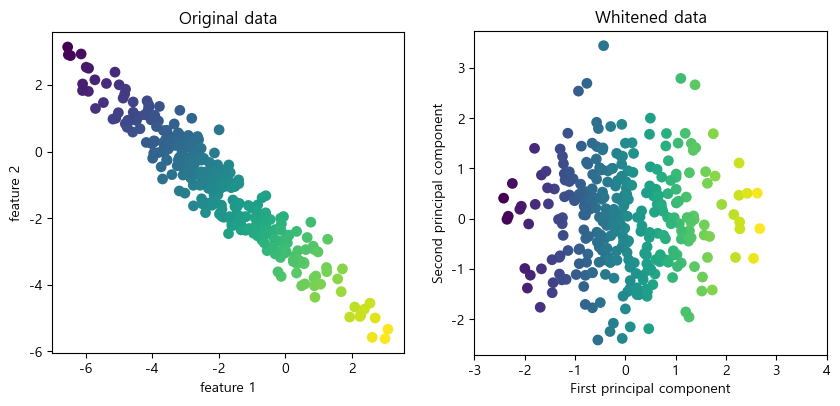

In [44]:
# PCA 화이트닝: 주성분의 스케일이 같아지도록 조정 (= PCA변환 후 StandardScaler 적용과 같음)
mglearn.plots.plot_pca_whitening()

In [45]:
# PCA 100개 주성분 추출 + 화이트닝
pca = PCA(n_components=100, whiten=True, random_state=0).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca  = pca.transform(X_test)

print('X_train_pca.shape:', X_train_pca.shape)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_pca, y_train)
print('테스트 세트 정확도:{:.2f}'.format(knn.score(X_test_pca, y_test)))

X_train_pca.shape: (1547, 100)
테스트 세트 정확도:0.30


pca.components_.shape: (100, 5655)


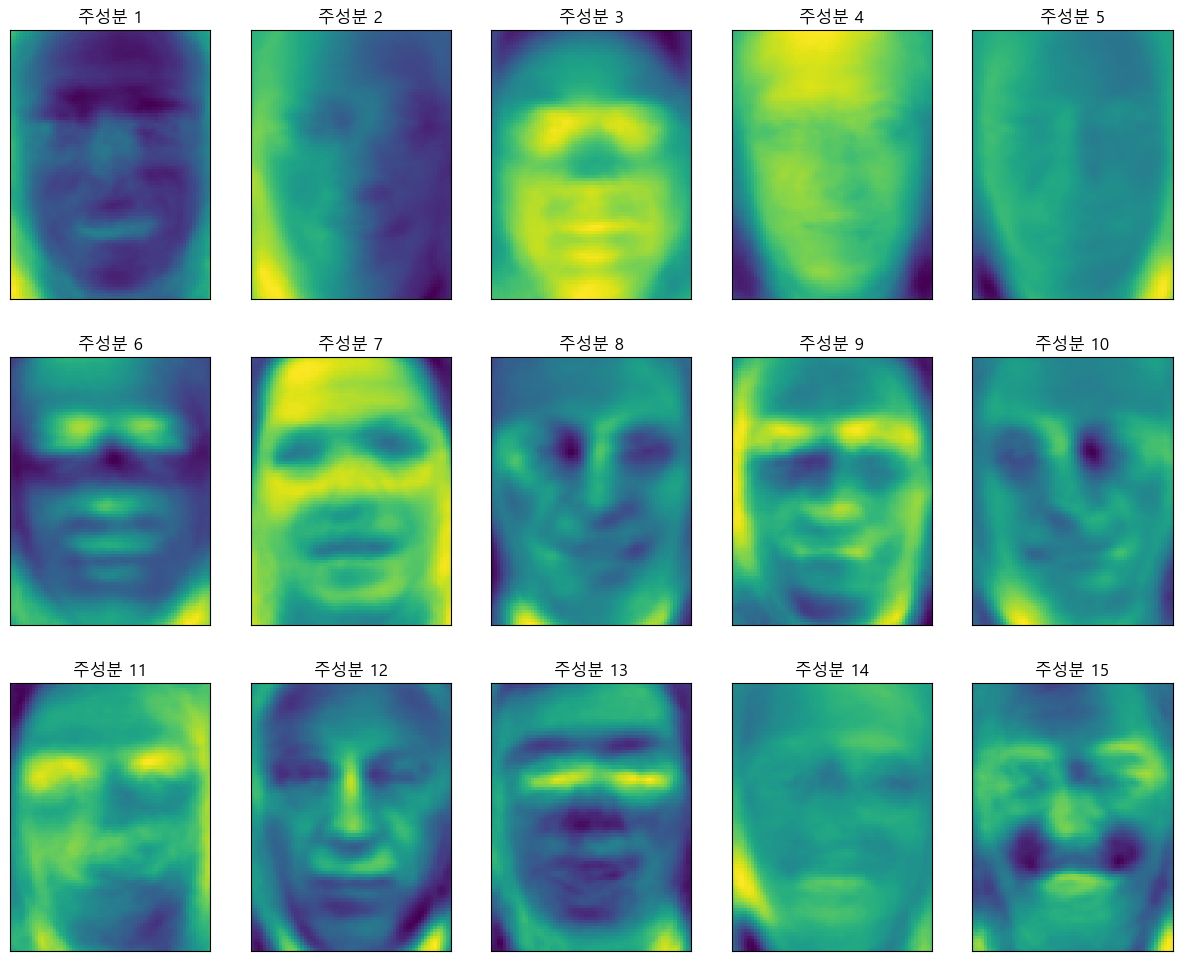

In [ ]:
# 주성분 시각화 (고유얼굴)
print('pca.components_.shape:', pca.components_.shape)

fig, axes = plt.subplots(3, 5, figsize=(15, 12),
                          subplot_kw={'xticks': (), 'yticks': ()})
for i, (component, ax) in enumerate(zip(pca.components_, axes.ravel())):
    ax.imshow(component.reshape(image_shape), cmap='viridis')
    ax.set_title('주성분 {}'.format(i + 1))
    #87x65

픽셀을 기반으로 하므로 얼굴의 배치와 조명이 두 이미지가 얼마나 비슷한지 판단하는 데 큰 영향을 줌

In [ ]:
# 주성분 개수별 얼굴 재구성 비교
mglearn.plots.plot_pca_faces(X_train, X_test, image_shape)

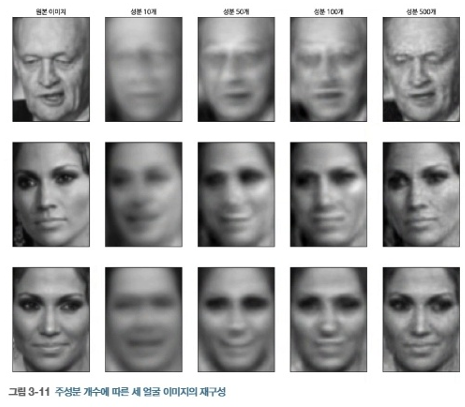

Text(0, 0.5, '두 번째 주성분')

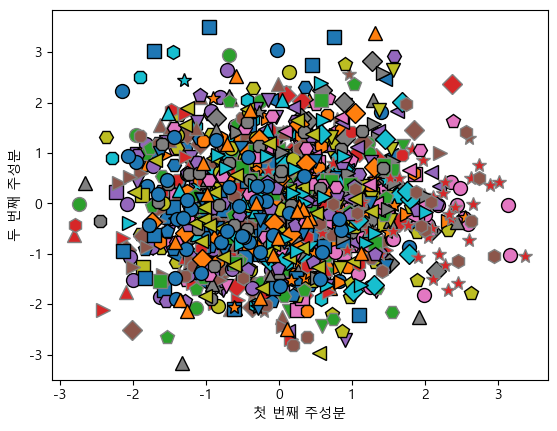

In [48]:
# 처음 두 주성분으로 산점도 (얼굴 데이터)
mglearn.discrete_scatter(X_train_pca[:, 0], X_train_pca[:, 1], y_train)
plt.xlabel('첫 번째 주성분')
plt.ylabel('두 번째 주성분')

0.8979817


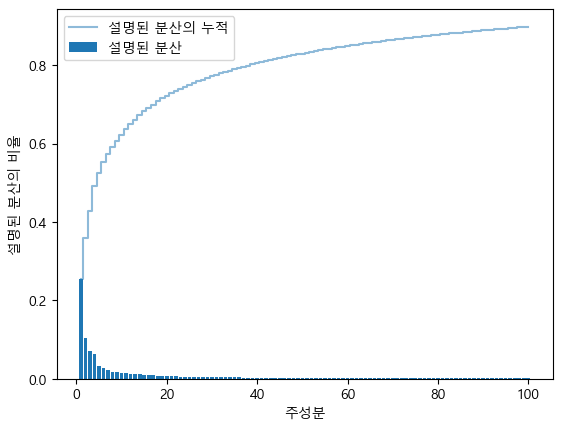

In [49]:
# 설명된 분산 비율 — 100개 주성분으로 전체 분산의 몇 %?
print(np.sum(pca.explained_variance_ratio_))

plt.bar(range(1, 101), pca.explained_variance_ratio_, align='center', label='설명된 분산')
plt.step(range(1, 101), np.cumsum(pca.explained_variance_ratio_),
         alpha=0.5, where='mid', label='설명된 분산의 누적')
plt.ylabel('설명된 분산의 비율')
plt.xlabel('주성분')
plt.legend()
plt.show()

In [50]:
# 주성분 40개로 줄여도 성능 비슷
pca = PCA(n_components=40, whiten=True, random_state=0).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca  = pca.transform(X_test)

knn.fit(X_train_pca, y_train)
print('테스트 세트 정확도: {:.2f}'.format(knn.score(X_test_pca, y_test)))

테스트 세트 정확도: 0.30


In [51]:
# n_components에 분산 비율(0~1)로 지정 가능
# n_components  : 내가 설정한 값 (0.8)
# n_components_ : 실제로 계산된 결과값
pca = PCA(n_components=0.8, whiten=True, random_state=0).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca  = pca.transform(X_test)

knn.fit(X_train_pca, y_train)
print('테스트 세트 정확도: {:.2f}'.format(knn.score(X_test_pca, y_test)))
print('주성분 개수:', pca.n_components_)

테스트 세트 정확도: 0.29
주성분 개수: 39


성능은 거의 동일함
나머지 주성분이 분류 작업에 큰 도움이 되지 않음
=> 주성분이 많다고 무조건 좋은 것이 아님

### 4.2 비음수 행렬 분해 (NMF)
유용한 특성을 뽑아내기 위한 비지도 학습 알고리즘

- 주성분과 계수가 모두 **0 이상** → 성분을 더하기만으로 조합 → 해석 가능
- 오디오(악기 분리), 텍스트(주제 분리), 이미지 패턴처럼 **여러 부분의 합**으로 이루어진 데이터에 유용
- PCA와 달리 모든 성분을 **동등하게** 취급 (순서 없음)
- 무작위 초기화 → random_state 설정 권장

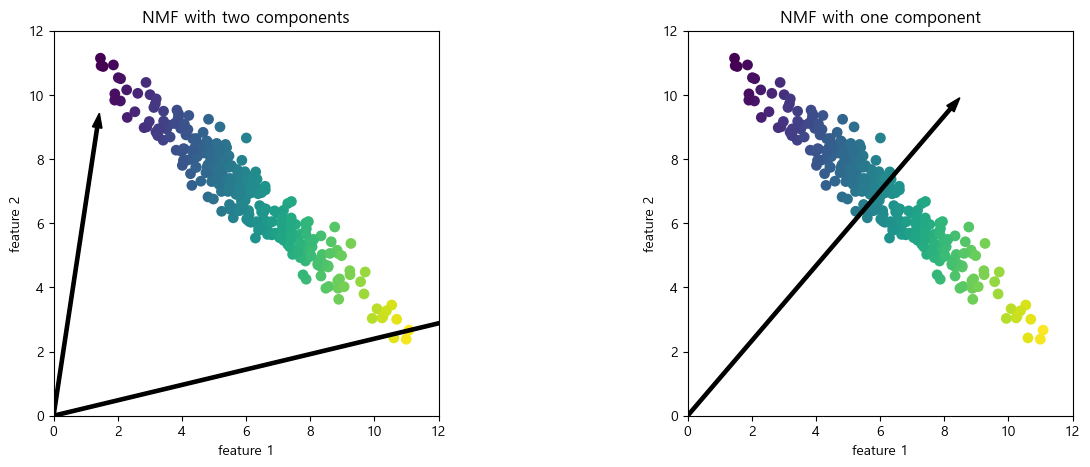

In [69]:
#원점에서 상대적으로 어디에 놓여 있는지 
mglearn.plots.plot_nmf_illustration()
# 각 특성

In [ ]:
# 얼굴 이미지에 NMF 적용
mglearn.plots.plot_nmf_faces(X_train, X_test[:3], image_shape)

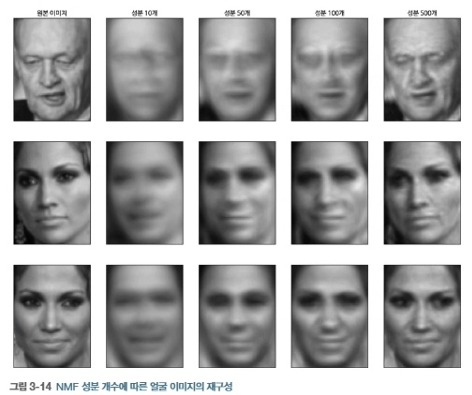

품질이 조금 떨어짐
NMF 인코딩하거나 재구성하는 용도로 사용하기보다는 주로 데이터에 있는 유용한 패턴을 찾는 데 활용함

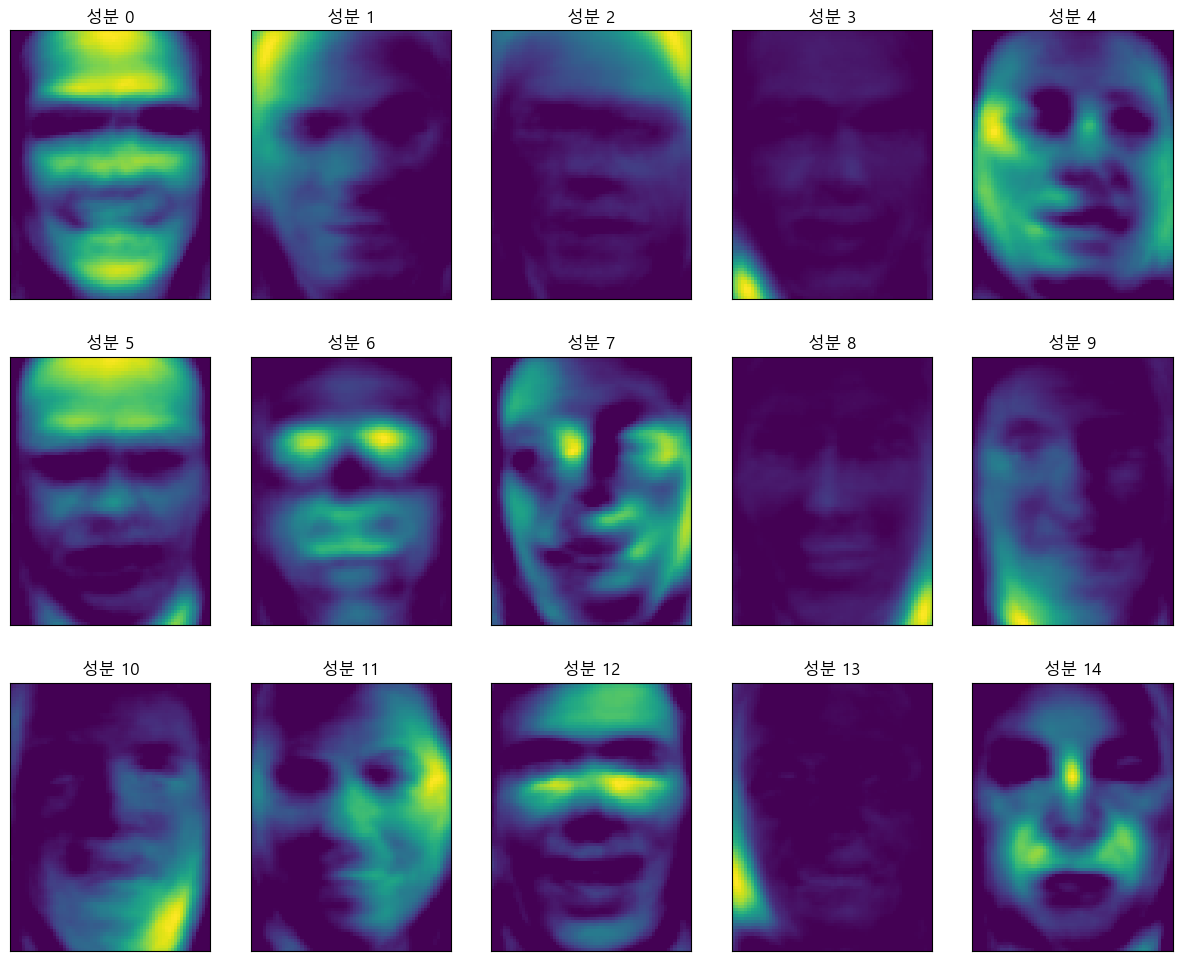

In [54]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=15, init='nndsvd', random_state=0, max_iter=1000, tol=1e-2)
nmf.fit(X_train)
X_train_nmf = nmf.transform(X_train)
X_test_nmf  = nmf.transform(X_test)

fig, axes = plt.subplots(3, 5, figsize=(15, 12),
                          subplot_kw={'xticks': (), 'yticks': ()})
for i, (component, ax) in enumerate(zip(nmf.components_, axes.ravel())):
    ax.imshow(component.reshape(image_shape))
    ax.set_title('성분 {}'.format(i))

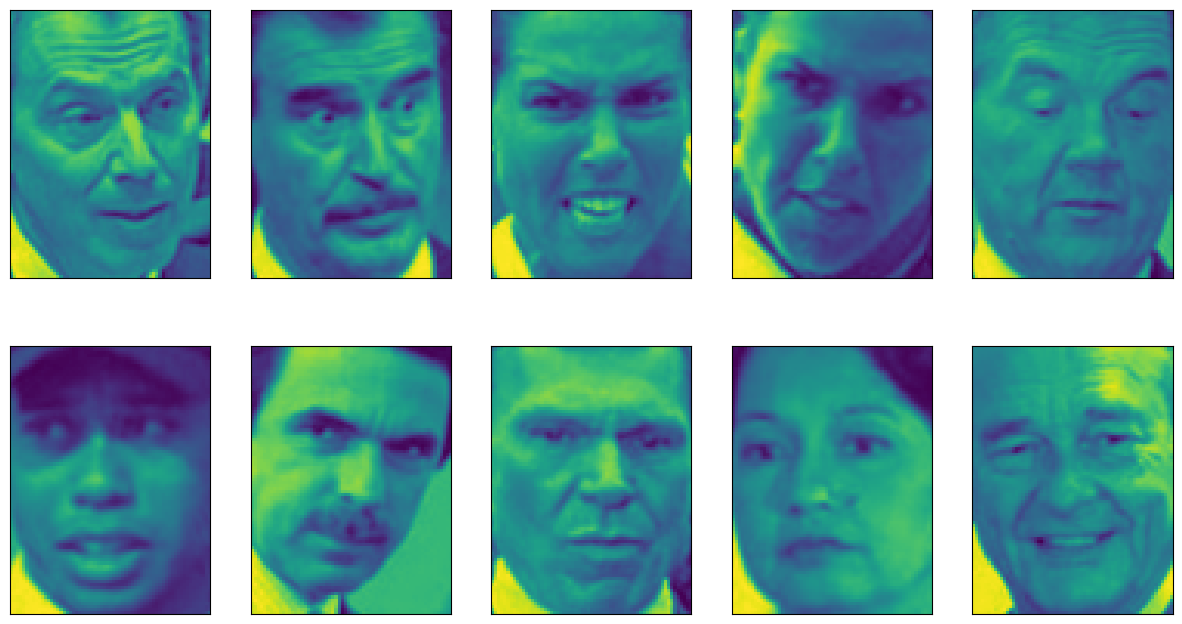

In [55]:
# 성분 3: 오른쪽으로 돌아간 얼굴
compn = 3
inds = np.argsort(X_train_nmf[:, compn])[::-1]
fig, axes = plt.subplots(2, 5, figsize=(15, 8),
                          subplot_kw={'xticks': (), 'yticks': ()})
for i, (ind, ax) in enumerate(zip(inds, axes.ravel())):
    ax.imshow(X_train[ind].reshape(image_shape))

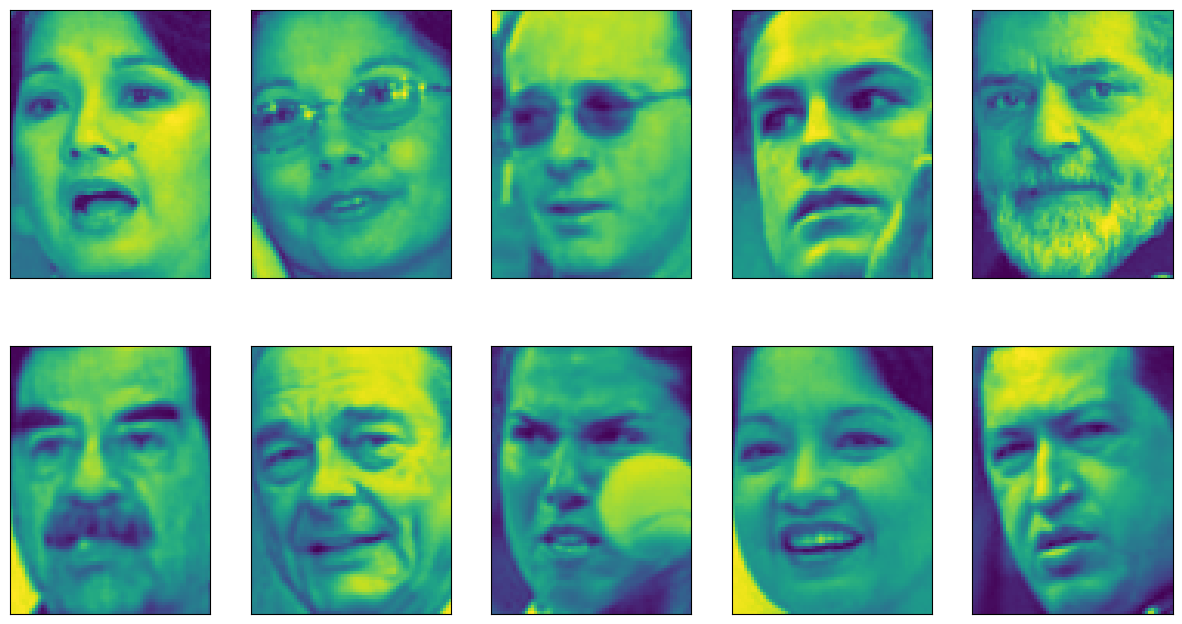

In [56]:
# 성분 7: 왼쪽으로 돌아간 얼굴
compn = 7
inds = np.argsort(X_train_nmf[:, compn])[::-1]
fig, axes = plt.subplots(2, 5, figsize=(15, 8),
                          subplot_kw={'xticks': (), 'yticks': ()})
for i, (ind, ax) in enumerate(zip(inds, axes.ravel())):
    ax.imshow(X_train[ind].reshape(image_shape))

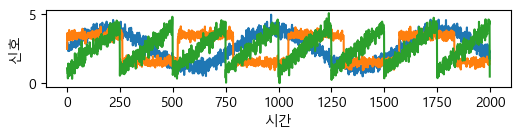

In [70]:
# 신호 분리 예제: 3개 원본 신호가 섞인 상태에서 NMF로 복원
S = mglearn.datasets.make_signals()
plt.figure(figsize=(6, 1))
plt.plot(S, '-')
plt.xlabel('시간')
plt.ylabel('신호')
plt.show()

In [58]:
# 원본 데이터를 사용해 100개의 측정 데이터를 만듦
A = np.random.RandomState(0).uniform(size=(100, 3))
X_sig = np.dot(S, A.T)
print('측정 데이터 형태:', X_sig.shape)

측정 데이터 형태: (2000, 100)


In [59]:
# NMF로 세 개의 신호 복원
nmf = NMF(n_components=3, init='nndsvd', random_state=42, max_iter=1000, tol=1e-2)
S_  = nmf.fit_transform(X_sig)
print('복원한 신호 데이터 형태:', S_.shape)

# 비교를 위해 PCA도 적용
pca = PCA(n_components=3)
H   = pca.fit_transform(X_sig)

복원한 신호 데이터 형태: (2000, 3)


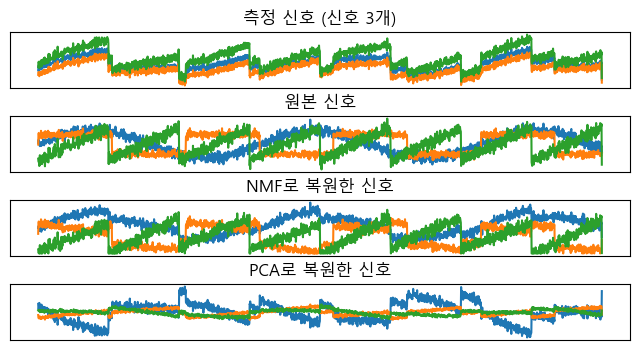

In [60]:
# NMF와 PCA로 찾은 신호 시각화
models = [X_sig, S, S_, H]
names  = ['측정 신호 (신호 3개)', '원본 신호', 'NMF로 복원한 신호', 'PCA로 복원한 신호']

fig, axes = plt.subplots(4, figsize=(8, 4),
                          gridspec_kw={'hspace': .5},
                          subplot_kw={'xticks': (), 'yticks': ()})
for model, name, ax in zip(models, names, axes):
    ax.set_title(name)
    ax.plot(model[:, :3], '-')
plt.show()

### 4.3 t-SNE를 이용한 매니폴드 학습
2차원 산점도를 이용해 시각화 용도로 많이 사용

- 데이터 포인트 사이의 거리를 가장 잘 보존하는 **2차원 표현**을 찾음
- 멀리 있는 포인트보다 **가까운 이웃**에 더 많은 비중
- 새 데이터에 적용 불가 (train 데이터만 변환) → **transform 없음, fit_transform만**
- 주요 매개변수: `perplexity`(이웃 개수, 기본값 30), `early_exaggeration`(클러스터 간격)

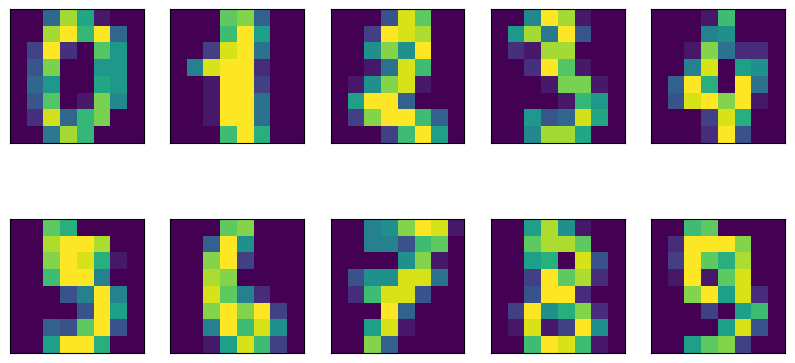

In [ ]:
# 손글씨 숫자 데이터셋 샘플 보기 /티스네
from sklearn.datasets import load_digits
digits = load_digits()

fig, axes = plt.subplots(2, 5, figsize=(10, 5),
                          subplot_kw={'xticks': (), 'yticks': ()})
for ax, img in zip(axes.ravel(), digits.images):
    ax.imshow(img)

Text(0, 0.5, '두 번째 주성분')

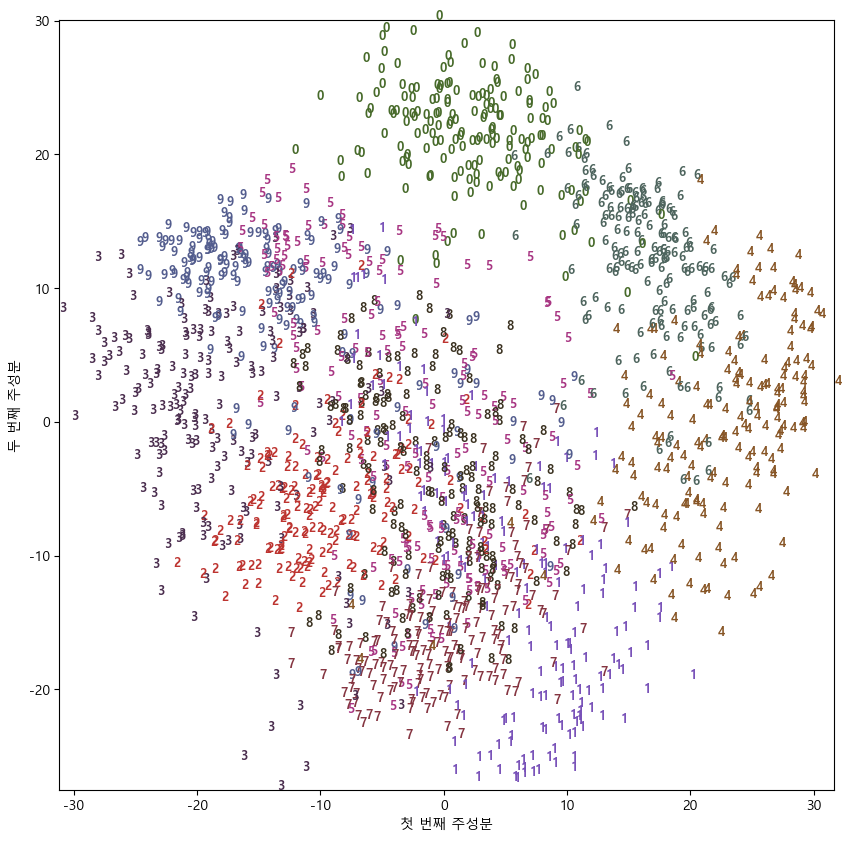

In [62]:
# PCA로 2차원 축소 후 시각화
pca = PCA(n_components=2)
pca.fit(digits.data)
digits_pca = pca.transform(digits.data)

colors = ['#476A2A', '#7851B8', '#BD3430', '#4A2D4E', '#875525',
          '#A83683', '#4E655E', '#853541', '#3A3120', '#535D8E']

plt.figure(figsize=(10, 10))
plt.xlim(digits_pca[:, 0].min(), digits_pca[:, 0].max())
plt.ylim(digits_pca[:, 1].min(), digits_pca[:, 1].max())
for i in range(len(digits.data)):
    plt.text(digits_pca[i, 0], digits_pca[i, 1], str(digits.target[i]),
             color=colors[digits.target[i]],
             fontdict={'weight': 'bold', 'size': 9})
plt.xlabel('첫 번째 주성분')
plt.ylabel('두 번째 주성분')

Text(0, 0.5, 't-SNE 특성 1')

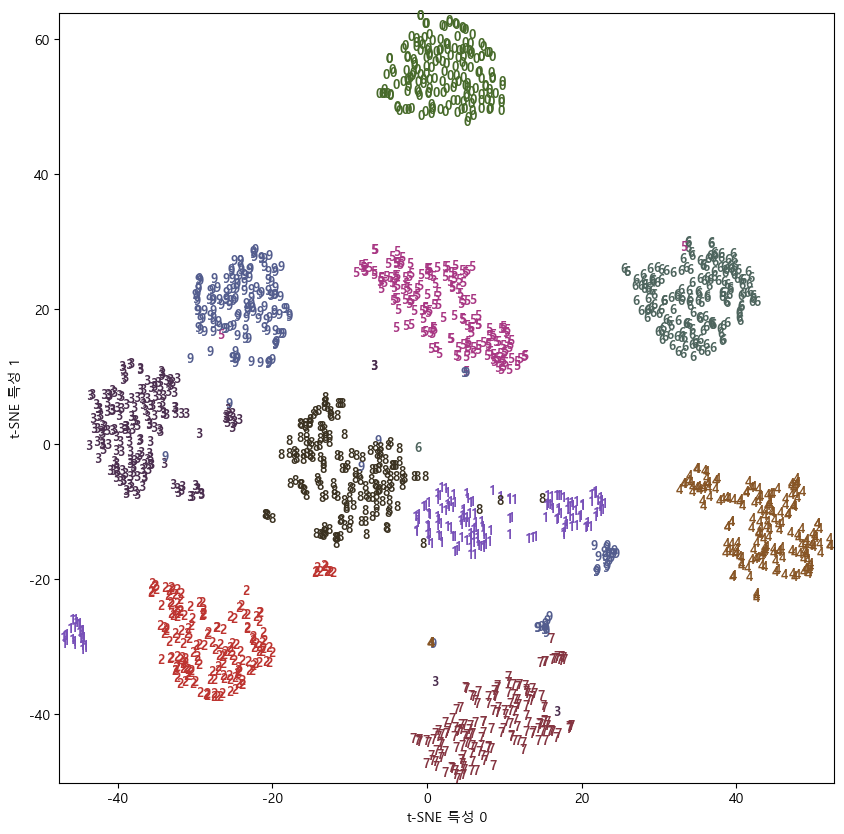

In [63]:
# t-SNE: TSNE에는 transform 없으므로 fit_transform 사용
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from sklearn.manifold import TSNE
tsne = TSNE(random_state=42)
digits_tsne = tsne.fit_transform(digits.data)

plt.figure(figsize=(10, 10))
plt.xlim(digits_tsne[:, 0].min(), digits_tsne[:, 0].max() + 1)
plt.ylim(digits_tsne[:, 1].min(), digits_tsne[:, 1].max() + 1)
for i in range(len(digits.data)):
    plt.text(digits_tsne[i, 0], digits_tsne[i, 1], str(digits.target[i]),
             color=colors[digits.target[i]],
             fontdict={'weight': 'bold', 'size': 9})
plt.xlabel('t-SNE 특성 0')
plt.ylabel('t-SNE 특성 1')